# Financial Sentiment Classification

## Deep Learning Models

Models implemented:
- Embedding + LSTM
- Embedding + GRU

### Import Libraries

In [147]:
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import seaborn as sns
import matplotlib.pyplot as plt

import pickle

### Load Processed Data

In [148]:
X_train = np.load("X_train.npy")
X_valid = np.load("X_valid.npy")

y_train = np.load("y_train.npy")
y_valid = np.load("y_valid.npy")


In [149]:
# check shapes

print(X_train.shape)
print(X_valid.shape)

(9543, 40)
(2388, 40)


### Load Vocabulary

In [150]:
with open("vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

vocab_size = len(vocab) + 1

print("Vocabulary size:", vocab_size)

Vocabulary size: 10001


### Convert to PyTorch Tensors

In [151]:
X_train = torch.tensor(X_train, dtype=torch.long)
X_valid = torch.tensor(X_valid, dtype=torch.long)

y_train = torch.tensor(y_train, dtype=torch.long)
y_valid = torch.tensor(y_valid, dtype=torch.long)

### Create Dataset Class

In [152]:
class TweetDataset(Dataset):

    def __init__(self, X, y):

        self.X = X
        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

### Create Dataset Objects And DataLoaders

In [153]:
train_dataset = TweetDataset(X_train, y_train)
valid_dataset = TweetDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)


### Compute Class Weights

In [154]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1,2]),
    y=y_train.numpy()
)

class_weights = torch.tensor(weights, dtype=torch.float)

print("Class Weights:", class_weights)



Class Weights: tensor([2.2060, 1.6542, 0.5149])


### Define LSTM Model

In [155]:
class LSTMModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim, 3)

    def forward(self, x):

        x = self.embedding(x)

        output, (hidden, _) = self.lstm(x)

        hidden = self.dropout(hidden[-1])

        out = self.fc(hidden)

        return out

### GRU Model

In [156]:
class GRUModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim, 3)

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.gru(x)

        hidden = self.dropout(hidden[-1])

        out = self.fc(hidden)

        return out

### Training Function

In [157]:
def train_model(model, train_loader, epochs=20):

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

    return model

### Evaluation Function

In [158]:
def evaluate_model(model, valid_loader):

    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():

        for X_batch, y_batch in valid_loader:

            outputs = model(X_batch)

            preds = torch.argmax(outputs, dim=1)

            predictions.extend(preds.numpy())
            true_labels.extend(y_batch.numpy())

    print(classification_report(true_labels, predictions))

    cm = confusion_matrix(true_labels, predictions)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return classification_report(true_labels, predictions, output_dict=True)

### Train LSTM

Epoch 1 | Loss: 1.0993
Epoch 2 | Loss: 1.0989
Epoch 3 | Loss: 1.0988
Epoch 4 | Loss: 1.0988
Epoch 5 | Loss: 1.0988
Epoch 6 | Loss: 1.0989
Epoch 7 | Loss: 1.0988
Epoch 8 | Loss: 1.0989
Epoch 9 | Loss: 1.0984
Epoch 10 | Loss: 1.0986
Epoch 11 | Loss: 1.0981
Epoch 12 | Loss: 1.0983
Epoch 13 | Loss: 1.0985
Epoch 14 | Loss: 1.0984
Epoch 15 | Loss: 1.0984
Epoch 16 | Loss: 1.0981
Epoch 17 | Loss: 1.0982
Epoch 18 | Loss: 1.0984
Epoch 19 | Loss: 1.0982
Epoch 20 | Loss: 1.0981


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       347
           1       0.00      0.00      0.00       475
           2       0.66      1.00      0.79      1566

    accuracy                           0.66      2388
   macro avg       0.22      0.33      0.26      2388
weighted avg       0.43      0.66      0.52      2388



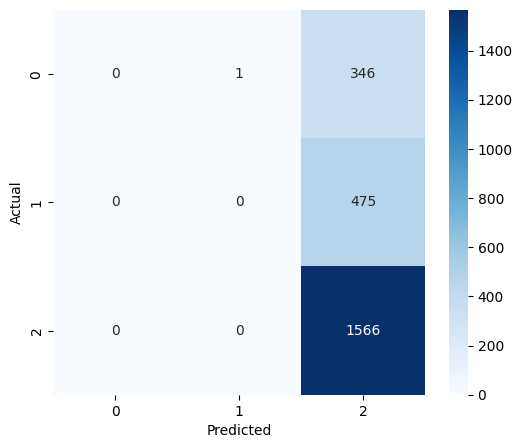

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [159]:
lstm_model = LSTMModel(vocab_size, 128, 128)

lstm_model = train_model(lstm_model, train_loader, epochs=20)

lstm_results = evaluate_model(lstm_model, valid_loader)

### Train GRU

Epoch 1 | Loss: 1.0993
Epoch 2 | Loss: 1.0969
Epoch 3 | Loss: 0.9583
Epoch 4 | Loss: 0.6957
Epoch 5 | Loss: 0.4549
Epoch 6 | Loss: 0.2816
Epoch 7 | Loss: 0.1653
Epoch 8 | Loss: 0.1029
Epoch 9 | Loss: 0.0772
Epoch 10 | Loss: 0.0467
Epoch 11 | Loss: 0.0371
Epoch 12 | Loss: 0.0278
Epoch 13 | Loss: 0.0256
Epoch 14 | Loss: 0.0318
Epoch 15 | Loss: 0.0298
Epoch 16 | Loss: 0.0152
Epoch 17 | Loss: 0.0151
Epoch 18 | Loss: 0.0180
Epoch 19 | Loss: 0.0190
Epoch 20 | Loss: 0.0143
              precision    recall  f1-score   support

           0       0.60      0.60      0.60       347
           1       0.68      0.66      0.67       475
           2       0.86      0.87      0.86      1566

    accuracy                           0.79      2388
   macro avg       0.71      0.71      0.71      2388
weighted avg       0.79      0.79      0.79      2388



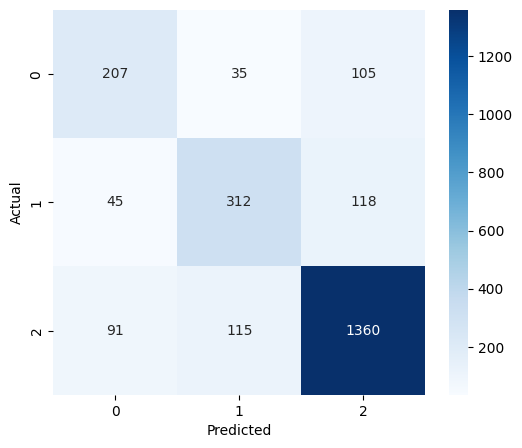

In [160]:
gru_model = GRUModel(vocab_size, 128, 128)

gru_model = train_model(gru_model, train_loader, epochs=20)

gru_results = evaluate_model(gru_model, valid_loader)

### Model Comparison

In [161]:
print("LSTM Macro F1:", lstm_results['macro avg']['f1-score'])
print("GRU Macro F1:", gru_results['macro avg']['f1-score'])

LSTM Macro F1: 0.26410321274981025
GRU Macro F1: 0.7099071503672852


### Bi-GRU Model

In [162]:
class BiGRUModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim * 2, 3)

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.gru(x)

        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        hidden = self.dropout(hidden)

        out = self.fc(hidden)

        return out

### Train Bi-GRU

Epoch 1 | Loss: 0.9121
Epoch 2 | Loss: 0.5807
Epoch 3 | Loss: 0.3469
Epoch 4 | Loss: 0.1896
Epoch 5 | Loss: 0.0951
Epoch 6 | Loss: 0.0481
Epoch 7 | Loss: 0.0311
Epoch 8 | Loss: 0.0171
Epoch 9 | Loss: 0.0162
Epoch 10 | Loss: 0.0494
Epoch 11 | Loss: 0.0268
Epoch 12 | Loss: 0.0118
Epoch 13 | Loss: 0.0165
Epoch 14 | Loss: 0.0175
Epoch 15 | Loss: 0.0242
Epoch 16 | Loss: 0.0143
Epoch 17 | Loss: 0.0073
Epoch 18 | Loss: 0.0040
Epoch 19 | Loss: 0.0040
Epoch 20 | Loss: 0.0030
              precision    recall  f1-score   support

           0       0.60      0.62      0.61       347
           1       0.71      0.66      0.69       475
           2       0.87      0.89      0.88      1566

    accuracy                           0.80      2388
   macro avg       0.73      0.72      0.73      2388
weighted avg       0.80      0.80      0.80      2388



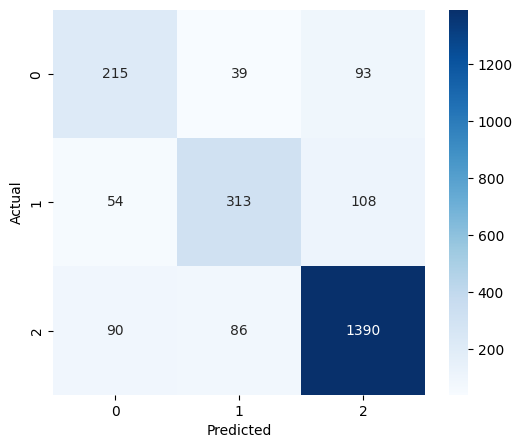

In [163]:
bigru_model = BiGRUModel(vocab_size, 200, 128)

bigru_model = train_model(bigru_model, train_loader, epochs=20)

bigru_results = evaluate_model(bigru_model, valid_loader)

### Compare All Models

In [164]:
print("LSTM Macro F1:", lstm_results['macro avg']['f1-score'])
print("GRU Macro F1:", gru_results['macro avg']['f1-score'])
print("Bi-GRU Macro F1:", bigru_results['macro avg']['f1-score'])

LSTM Macro F1: 0.26410321274981025
GRU Macro F1: 0.7099071503672852
Bi-GRU Macro F1: 0.7250998951031998


Three models were implemented: LSTM, GRU, and Bidirectional GRU.

The LSTM model struggled due to class imbalance and converged to predicting the majority class.

The GRU model significantly improved performance, achieving a macro F1-score of 0.71.

Further improvement was achieved using a Bidirectional GRU, which captures contextual information from both directions. This resulted in a macro F1-score of 0.73 and accuracy of 80%, making it the best-performing model.

### Saving Models

In [ ]:
torch.save(lstm_model.state_dict(), "lstm_model.pt")
torch.save(gru_model.state_dict(), "gru_model.pt")
torch.save(bigru_model.state_dict(), "bigru_model.pt")